In [1]:
"""Environment setup and library imports for Conv1D training.

Sets Keras JAX backend and configures JAX precision and memory allocation behavior.
"""

import glob
import os
import pickle
import random
import warnings

os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.7"

import jax

# Enable JAX float64 precision natively
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import keras
from keras import callbacks, layers, regularizers
import numpy as np
import polars as pl

warnings.filterwarnings("ignore")

# Show enough digits to round-trip float64 diagnostics
np.set_printoptions(precision=17, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")


2026-08-03 15:04:15.101390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785758655.114058  233333 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785758655.118838  233333 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version : 3.12.0
Keras backend : jax
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks


In [2]:
def find_data_dir() -> str:
    """Searches common Kaggle and local mount points for the ROGII dataset.

    Returns:
        str: Path to the dataset directory containing 'train' subdirectory.

    Raises:
        FileNotFoundError: If the dataset cannot be found in any candidate path.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        n_train = 0
        if has_train:
            n_train = len(
                glob.glob(os.path.join(path, "train", "*__horizontal_well.csv"))
            )

        if n_train > 0:
            print(f"  V Using {path} (found {n_train} train wells)")
            return path

    raise FileNotFoundError("Could not find ROGII dataset.")


DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  V Using /home/samer/Documents/competitions/ROGII/dataset (found 773 train wells)


### Data preparation

In [3]:
"""Data loading, preprocessing and preparation functions using Polars and JAX.

The Conv1D model is trained with a test-like TVT_input mask. In the competition test
wells, TVT_input is known before the submission interval and missing throughout the
interval that must be predicted. If validation keeps the true TVT_input, the model can
learn an identity shortcut and report unrealistically low validation RMSE.
"""

from typing import Dict, List, Tuple, Union
import glob
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
import polars as pl

# Add geology-aware features to the input list
FEATURE_COLS: List[str] = [
    "MD", "X", "Y", "Z", "GR", "TVT_input", # Base features
    "inclination",                   # Engineered Feature 1
    "GR_mean_50",                    # Engineered Feature 2
    "GR_std_50",                     # Engineered Feature 3
    "dist_to_buda"                   # Engineered Feature 4
]
# Base features required for preprocessing and feature engineering.
# Includes geological markers needed for distance calculations.
BASE_FEATURE_COLS: List[str] = [
    "MD", "X", "Y", "Z", "GR", "TVT_input",
    "ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"
]
TARGET: str = "TVT"
TVT_INPUT_COL: str = "TVT_input"
MASK_START_RATIO_RANGE: Tuple[float, float] = (0.20, 0.40)


def mask_tvt_input_for_prediction_zone(
    df: pl.DataFrame,
    rng: np.random.Generator,
    ratio_range: Tuple[float, float] = MASK_START_RATIO_RANGE,
) -> Tuple[pl.DataFrame, int]:
    """Masks a suffix of TVT_input to mimic the hidden test prediction interval.

    Args:
        df (pl.DataFrame): Input DataFrame containing the well data.
        rng (np.random.Generator): Random number generator for reproducibility.
        ratio_range (Tuple[float, float]): Range of mask start ratio relative
          to well depth.

    Returns:
        Tuple[pl.DataFrame, int]: A tuple containing the masked DataFrame and
          the index where the masking started.
    """
    if TVT_INPUT_COL not in df.columns or len(df) < 2:
        return df, len(df)

    low, high = ratio_range
    mask_start = int(round(len(df) * rng.uniform(low, high)))
    mask_start = min(max(mask_start, 1), len(df) - 1)
    row_nr = pl.int_range(0, pl.len())
    df = df.with_columns(
        pl.when(row_nr >= mask_start)
        .then(None)
        .otherwise(pl.col(TVT_INPUT_COL))
        .alias(TVT_INPUT_COL)
    )
    return df, mask_start


def preprocess(df: pl.DataFrame) -> pl.DataFrame:
    """Interpolates nulls and engineers geology-aware features.

    This function now calculates:
    1. Wellbore Inclination: Captures the angle of drilling.
    2. Rolling GR Mean (50): Smooths the Gamma Ray signal.
    3. Rolling GR Std Dev (50): Captures the texture/variability of the formation.
    4. Distance to Buda Marker: Provides relative stratigraphic position.

    Args:
        df (pl.DataFrame): Input DataFrame with missing values.

    Returns:
        pl.DataFrame: Preprocessed DataFrame with all feature columns filled.
    """
    # 1. Interpolate base features and markers first
    for col in BASE_FEATURE_COLS:       
         if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )

    # 2. Engineer new features from the cleaned GR and MD columns
    df = df.with_columns(
        # 1. Wellbore Inclination
        ((pl.col("Z").diff().fill_null(0)) / (pl.col("MD").diff().fill_null(1e-6)))
        .clip(-1.0, 1.0)  # Ensure input to arcsin is in [-1, 1]
        .map_elements(np.arcsin, return_dtype=pl.Float64).alias("inclination"),

        # 2. Rolling GR Mean (window 50)
        pl.col("GR").rolling_mean(window_size=50).alias("GR_mean_50"),

        # 3. Rolling GR Standard Deviation (window 50)
        pl.col("GR").rolling_std(window_size=50).alias("GR_std_50"),

        # 4. Distance to Buda Marker
        (pl.col("Z") - pl.col("BUDA")).alias("dist_to_buda")
    )

    # 3. Fill nulls generated by rolling windows and diffs
    return df.with_columns(
        pl.all().forward_fill().backward_fill().fill_null(0.0)
    )


def prepare_data(
    data_dir: str,
    val_ratio: float = 0.20,
    seed: int = 42,
    max_wells: Union[int, None] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """Loads wells and builds train/validation arrays with test-like masking.

    Reshapes the inputs to 3D tensors compatible with Conv1D layers and uses JAX
    on CPU memory for double-precision normalization to avoid GPU OOM.

    Args:
        data_dir (str): Path to the training dataset.
        val_ratio (float): Fraction of wells to use for validation.
        seed (int): Random seed for split and masking reproducibility.
        max_wells (Union[int, None]): Maximum number of wells to load (for debugging).

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
          A tuple containing:
            - X_train: Preprocessed standardized training features (3D: [samples, 1, features]).
            - y_train: Standardized training target values (1D: [samples]).
            - X_val: Preprocessed standardized validation features (3D: [samples, 1, features]).
            - y_val: Standardized validation target values (1D: [samples]).
            - y_val_raw: Raw validation targets in original scale (1D: [samples]).
            - scaler: Dictionary containing standardization scaling parameters.
    """
    dataset_root = os.path.dirname(data_dir)

    # 1. Get original training IDs
    pattern_train = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    files_train = sorted([os.path.basename(f) for f in glob.glob(pattern_train)])

    # 2. Get augmented training files
    # pattern_aug = os.path.join(
    #     dataset_root, "dataset_augmented", "train", "*__horizontal_well_aug.csv"
    # )
    # files_aug = sorted([os.path.basename(f) for f in glob.glob(pattern_aug)])

    # Combined training file list
    files_train_all = files_train #+ files_aug

    if max_wells:
        files_train_all = files_train_all[:max_wells]

    rng = np.random.default_rng(seed)
    n_val = max(1, int(len(files_train_all) * val_ratio))
    val_set = set(rng.permutation(len(files_train_all))[:n_val])

    train_files = [fname for i, fname in enumerate(files_train_all) if i not in val_set]
    val_files = [fname for i, fname in enumerate(files_train_all) if i in val_set]

    print(
        f"Loading {len(files_train_all)} training wells total. "
        # f"(Original: {len(files_train)}, Augmented: {len(files_aug)})."
    )

    def get_arrays(files: List[str], split_name: str) -> Tuple[np.ndarray, np.ndarray]:
        """Reads CSV files for a split, masks TVT_input, and returns merged arrays.

        Args:
            files (List[str]): List of filenames to load.
            split_name (str): Label for the dataset split (e.g. "Train", "Val").

        Returns:
            Tuple[np.ndarray, np.ndarray]: Merged features and target arrays.
        """
        feats, tgts, mask_starts = [], [], []
        for filename in files:
            try:
                # if filename in files_aug:
                #     path = os.path.join(
                #         dataset_root, "dataset_augmented", "train", filename
                #     )
                # else:
                path = os.path.join(data_dir, "train", filename)

                df = pl.read_csv(path, infer_schema_length=10000)
                df = df.filter(pl.col(TARGET).is_not_null())
                if len(df) == 0:
                    continue

                df, mask_start = mask_tvt_input_for_prediction_zone(df, rng)
                df = preprocess(df)

                feats.append(df.select(FEATURE_COLS).to_numpy().astype(np.float64))
                tgts.append(df.select(TARGET).to_numpy().ravel().astype(np.float64))
                mask_starts.append(mask_start / len(df))
            except Exception as e:
                print(f"  Skip {filename}: {e}")

        if not feats:
            raise ValueError(f"No usable wells found for {split_name} split.")

        print(
            f"{split_name} TVT_input mask start ratio: "
            f"mean={np.mean(mask_starts):.3f}, "
            f"min={np.min(mask_starts):.3f}, max={np.max(mask_starts):.3f}"
        )
        return np.concatenate(feats), np.concatenate(tgts)

    X_train_raw, y_train_raw = get_arrays(train_files, "Train")
    X_val_raw, y_val_raw = get_arrays(val_files, "Val")

    cpu_dev = jax.devices("cpu")[0]
    X_tr_jax = jax.device_put(X_train_raw, cpu_dev)
    y_tr_jax = jax.device_put(y_train_raw, cpu_dev)
    X_val_jax = jax.device_put(X_val_raw, cpu_dev)
    y_val_jax = jax.device_put(y_val_raw, cpu_dev)

    feat_mean = jnp.mean(X_tr_jax, axis=0)
    feat_std = jnp.std(X_tr_jax, axis=0)
    feat_std = jnp.where(feat_std == 0, 1.0, feat_std)

    target_mean = jnp.mean(y_tr_jax)
    target_std = jnp.std(y_tr_jax)
    target_std = jnp.where(target_std == 0, 1.0, target_std)

    X_train_n = (X_tr_jax - feat_mean) / feat_std
    y_train_n = (y_tr_jax - target_mean) / target_std
    X_val_n = (X_val_jax - feat_mean) / feat_std
    y_val_n = (y_val_jax - target_mean) / target_std

    scaler = {
        "feature_cols": FEATURE_COLS,
        "feat_mean": np.array(feat_mean),
        "feat_std": np.array(feat_std),
        "target_mean": float(target_mean),
        "target_std": float(target_std),
        "normalized": True,
        "tvt_input_masked_for_training": True,
        "mask_start_ratio_range": MASK_START_RATIO_RANGE,
    }

    # Reshape features to 3D format (samples, sequence_length=1, features) for Conv1D compatibility
    X_train_3d = np.array(X_train_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))
    X_val_3d = np.array(X_val_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))

    return (
        X_train_3d,
        np.array(y_train_n, dtype=np.float32),
        X_val_3d,
        np.array(y_val_n, dtype=np.float32),
        y_val_raw,
        scaler,
    )


print("Preparing dataset...")
X_train, y_train, X_val, y_val, y_val_raw, scaler = prepare_data(DATA_DIR)
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
scaler_path = os.path.join(OUT_DIR, "conv_tr_scaler_params.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler parameters saved to {scaler_path}")


Preparing dataset...
Loading 773 training wells total. 
Train TVT_input mask start ratio: mean=0.301, min=0.200, max=0.400
Val TVT_input mask start ratio: mean=0.295, min=0.200, max=0.399
Train size: (4074081, 1, 10), Val size: (1018174, 1, 10)
Scaler parameters saved to ../outputs/conv_tr_scaler_params.pkl


### Model building

In [4]:
"""Model construction and compilation for Conv1D architecture."""

def se_block(x, ratio=8):
    """Applies Squeeze-and-Excitation channel attention."""
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(channels // ratio, 4), activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, channels))(se)
    return layers.Multiply()([x, se])

def transformer_encoder_block(x, num_heads=8, key_dim=128, dropout=0.1):
    """Builds a Transformer encoder block for sequence feature learning.

    Args:
        x: Input tensor of shape (batch, steps, channels).
        num_heads: Number of attention heads.
        key_dim: Dimensionality of the key/query/value.
        dropout: Dropout rate.

    Returns:
        Output tensor of the Transformer block.
    """
    # Self-attention layer
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    # Feed-forward network (no expansion, just normalization)
    return out1


def residual_conv1d_block(x, filters, kernel_size, dropout_rate=0.2):
    """Builds a residual Conv1D block with BatchNorm and SE attention."""
    shortcut = x
    y = layers.Conv1D(
        filters,
        kernel_size,
        padding="causal",
        kernel_initializer="he_uniform",
        kernel_regularizer=regularizers.l2(1e-4),
    )(x)
    y = layers.BatchNormalization()(y)
    y = layers.LeakyReLU(negative_slope=0.5)(y)
    y = layers.Conv1D(
        filters,
        kernel_size,
        padding="causal",
        kernel_initializer="he_uniform",
        kernel_regularizer=regularizers.l2(1e-4),
    )(y)
    y = layers.BatchNormalization()(y)
    y = se_block(y)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(
            filters,
            1,
            padding="same",
            kernel_initializer="he_uniform",
            kernel_regularizer=regularizers.l2(1e-4),
        )(shortcut)

    y = layers.Add()([shortcut, y])
    y = layers.LeakyReLU(negative_slope=0.5)(y)
    y = layers.Dropout(dropout_rate)(y)
    return y


def build_improved_conv1d_model(input_dim: int) -> keras.Model:
    """Builds and compiles the improved Residual Conv1D + SE model."""
    inputs = layers.Input(shape=(1, input_dim), name="input_layer")

    # 1. Use Conv1D blocks to extract local, scale-invariant features
    x = residual_conv1d_block(inputs, filters=64, kernel_size=8, dropout_rate=0.3)
    x = residual_conv1d_block(x, filters=128, kernel_size=8, dropout_rate=0.3)

    # 2. Use a Transformer to learn long-range dependencies between the extracted features
    x = transformer_encoder_block(x, num_heads=8, key_dim=128, dropout=0.3)

    # 3. Final MLP head for regression

    x = layers.Flatten()(x)
    x = layers.Dense(
        128,
        kernel_initializer="he_uniform",
        kernel_regularizer=regularizers.l2(1e-5),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.5)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(
        64,
        kernel_initializer="he_uniform",
        kernel_regularizer=regularizers.l2(1e-5),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.5)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="linear")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = keras.optimizers.AdamW(
        learning_rate=5e-6,  # Slightly increased LR for the larger model
        weight_decay=1e-4,
        global_clipnorm=1.0,
    )
    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


model = build_improved_conv1d_model(input_dim=len(FEATURE_COLS))
print("Conv1D + Transformer Hybrid model built and compiled successfully.")
model.summary()


Conv1D + Transformer Hybrid model built and compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 64)     │      5,184 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1, 64)     │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 1, 64)     │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 64)     │     32,832 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64)     │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 64)     │        704 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 64)     │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 64)     │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 1, 64)     │          0 │ add[0][0]         │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 128)    │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 128)    │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 1, 128)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1, 128)    │    131,200 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 128)    │        512 │ conv1d_4[0][0]  

 Total params: 804,121 (3.07 MB)

 Trainable params: 802,969 (3.06 MB)

 Non-trainable params: 1,152 (4.50 KB)

### Training

In [ ]:
"""Train the Conv1D model with ModelCheckpoint, ReduceLROnPlateau, and EarlyStopping."""

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUT_DIR, "trained_conv1d_se_model.keras")

cbs = [
    callbacks.ModelCheckpoint(
        best_model_path, monitor="val_rmse", save_best_only=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5, patience=5, min_lr=5e-8
    ),
    # callbacks.EarlyStopping(monitor="val_rmse", patience=20, restore_best_weights=True),
]

print("Starting training of the Conv1D model...")
history = model.fit(
    X_train,
    y_train,
    epochs=2000,
    validation_data=(X_val, y_val),
    batch_size=1024,
    callbacks=cbs,
)


Starting training of the Conv1D model...
Epoch 1/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 70s 12ms/step - loss: 0.7307 - rmse: 0.7944 - val_loss: 0.1937 - val_rmse: 0.3298 - learning_rate: 5.0000e-06
Epoch 2/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.4228 - rmse: 0.5891 - val_loss: 0.1354 - val_rmse: 0.2591 - learning_rate: 5.0000e-06
Epoch 3/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.3238 - rmse: 0.5105 - val_loss: 0.1084 - val_rmse: 0.2221 - learning_rate: 5.0000e-06
Epoch 4/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.2593 - rmse: 0.4505 - val_loss: 0.0941 - val_rmse: 0.1999 - learning_rate: 5.0000e-06
Epoch 5/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.2130 - rmse: 0.4003 - val_loss: 0.0846 - val_rmse: 0.1822 - learning_rate: 5.0000e-06
Epoch 6/2000
3979/3979 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 0.1777 - rmse: 0.3568 - val_loss: 0.0771 - val_rmse: 0.1666 - learning_rate: 5.0000e-06
Epoch 7/2000
3979/3979 ━━━━━━━━━━━━━━━━━

### Evaluation

In [ ]:
"""Load the best model and evaluate its final RMSE on raw scale using JAX."""

# Denormalize using JAX on CPU device
cpu_dev = jax.devices("cpu")[0]
target_mean = jax.device_put(scaler["target_mean"], cpu_dev)
target_std = jax.device_put(scaler["target_std"], cpu_dev)
y_val_raw_jnp = jax.device_put(y_val_raw, cpu_dev)

# Predict on val set (normalized scale)
yp_n = model.predict(X_val, batch_size=128).ravel()
yp_n_jnp = jax.device_put(yp_n, cpu_dev)

# Denormalize predictions
yp_jnp = (yp_n_jnp * target_std) + target_mean

# Calculate error and RMSE using JAX
err = yp_jnp - y_val_raw_jnp
rmse = float(jnp.sqrt(jnp.mean(jnp.square(err))))
print(f"\nFinal Val RMSE (Optimized Conv1D Model, RAW SCALE): {rmse:.4f}")


7955/7955 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step

Final Val RMSE (Optimized Conv1D Model, RAW SCALE): 40.3881


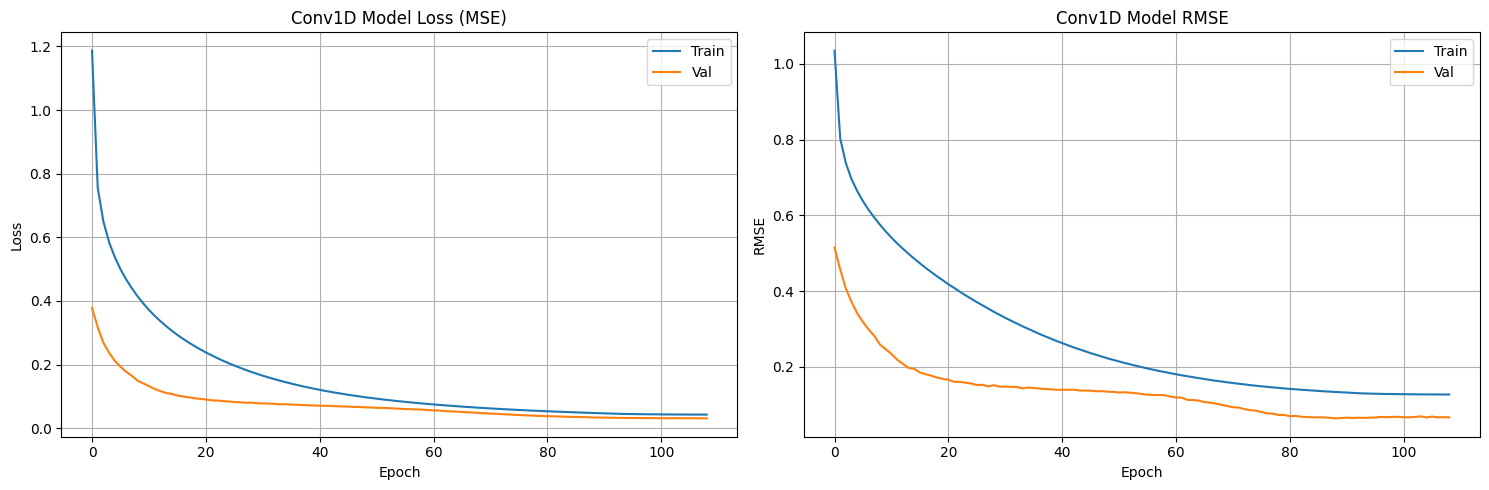

In [ ]:
"""Plots training and validation curves and saves them to the analytics directory."""

import matplotlib.pyplot as plt

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_history(history):
    """Plots model loss and root mean squared error curves.

    Args:
        history: Keras History object.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curve
    ax1.plot(history.history["loss"], label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Conv1D Model Loss (MSE)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # RMSE curve
    ax2.plot(history.history["rmse"], label="Train")
    ax2.plot(history.history["val_rmse"], label="Val")
    ax2.set_title("Conv1D Model RMSE")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("RMSE")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "conv1d_training_history.png"))
    plt.show()


if "history" in locals():
    plot_history(history)


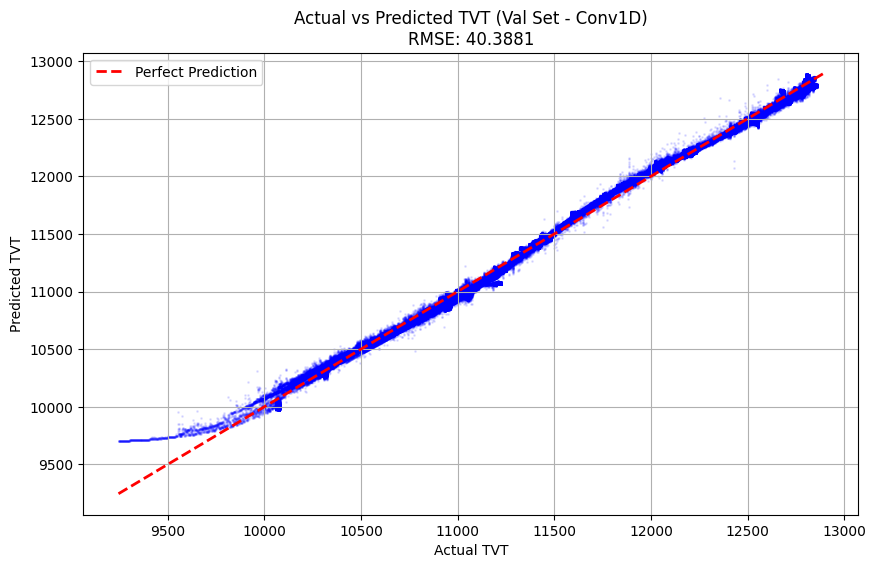

In [ ]:
def plot_pred_vs_actual(y_true, y_pred, val_rmse):
    """Plots predicted vs actual values on raw scale and saves it to analytics."""
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(y_true), np.array(y_pred), alpha=0.1, s=1, color="blue")

    # Draw perfect prediction line
    min_val = min(float(y_true.min()), float(y_pred.min()))
    max_val = max(float(y_true.max()), float(y_pred.max()))
    plt.plot(
        [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction"
    )

    plt.title(f"Actual vs Predicted TVT (Val Set - Conv1D)\nRMSE: {val_rmse:.4f}")
    plt.xlabel("Actual TVT")
    plt.ylabel("Predicted TVT")
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(ANALYTICS_DIR, "conv1d_val_pred_vs_actual.png"))
    plt.show()


if "y_val_raw" in locals() and "yp_jnp" in locals():
    plot_pred_vs_actual(y_val_raw, yp_jnp, rmse)
